# Figure 5 panel F - DRB1 high-risk heatmap


In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# --- Manuscript plotting style ---
axis_label_font_size = 7
tick_label_font_size = 6
anno_font_size = 5
plt.rcParams.update({
    'font.size': axis_label_font_size,
    'axes.titlesize': axis_label_font_size,
    'axes.labelsize': axis_label_font_size,
    'xtick.labelsize': tick_label_font_size,
    'ytick.labelsize': tick_label_font_size,
    'legend.fontsize': tick_label_font_size,
    'legend.title_fontsize': axis_label_font_size,
})
c_attention = '#378ADD'

# --- Input path ---
DRB1_RISK_TABLE = 'intermediate_data/panel_f_drb1_risk_matrix.csv'

# --- Output path ---
FIGURE_DIR = 'figures/'
os.makedirs(FIGURE_DIR, exist_ok=True)

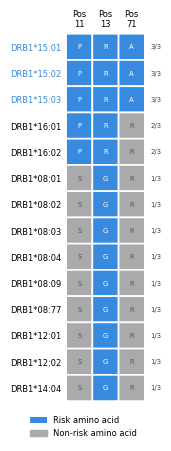

In [3]:
def plot_hla_risk_heatmap(
    risk_table_path,
    out_name,
    figsize,
    cell_text_fontsize,
    tick_fontsize,
    score_fontsize,
    legend_fontsize,
    legend_labels=("Risk amino acid", "Non-risk amino acid"),
    legend_bbox_to_anchor=(1.0, -0.08),
    figure_dir=FIGURE_DIR,
):
    """Regenerate one allele x position risk-residue heatmap from its
    saved intermediate table (see `build_risk_matrix_table` in
    panel_f_data_generation_20260823.ipynb)."""
    df = pd.read_csv(risk_table_path)

    # Reconstruct the allele order (already risk-score-sorted, descending)
    # and position order exactly as written by the data-generation notebook.
    allele_list_sorted = df['allele'].drop_duplicates().tolist()
    n_alleles = len(allele_list_sorted)
    positions = df.loc[df['allele'] == allele_list_sorted[0], 'position'].tolist() if n_alleles else []
    n_cols = len(positions)
    n_rows = n_alleles

    row_labels = [
        df.loc[df['allele'] == a, 'allele_label'].iloc[0] for a in allele_list_sorted
    ]
    col_labels = [f"Pos\n{p}" for p in positions]

    cell_aa = [
        df.loc[df['allele'] == a].set_index('position').loc[positions, 'residue'].tolist()
        for a in allele_list_sorted
    ]
    cell_risk = [
        df.loc[df['allele'] == a].set_index('position').loc[positions, 'is_risk'].tolist()
        for a in allele_list_sorted
    ]
    risk_scores = {a: df.loc[df['allele'] == a, 'risk_score'].iloc[0] for a in allele_list_sorted}

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows)
    ax.invert_yaxis()
    ax.set_aspect("equal")

    RISK_COLOR = c_attention
    NONRISK_COLOR = "#AAAAAA"
    TEXT_ON_RISK = "white"
    TEXT_ON_NRISK = "#555555"

    for r, allele_key in enumerate(allele_list_sorted):
        is_drb15_block = allele_key.startswith("hla_drb1_15")
        for c in range(n_cols):
            aa = cell_aa[r][c]
            risk = cell_risk[r][c]
            color = RISK_COLOR if risk else NONRISK_COLOR
            rect = mpatches.FancyBboxPatch(
                (c + 0.04, r + 0.04), 0.92, 0.92,
                boxstyle="round,pad=0.04",
                facecolor=color, edgecolor="white", linewidth=1.2,
            )
            ax.add_patch(rect)
            ax.text(
                c + 0.5, r + 0.5, aa, ha="center", va="center",
                fontsize=cell_text_fontsize,
                color=TEXT_ON_RISK if risk else TEXT_ON_NRISK,
            )
        if is_drb15_block:
            ax.plot([-0.35, -0.35], [r + 0.1, r + 0.9], color='#D85A30', linewidth=3, solid_capstyle="round")

    ax.set_xticks([c + 0.5 for c in range(n_cols)])
    ax.set_xticklabels(col_labels, fontsize=tick_fontsize)
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")

    ax.set_yticks([r + 0.5 for r in range(n_rows)])
    ax.set_yticklabels(row_labels, fontsize=tick_fontsize)

    for tick, allele_key in zip(ax.yaxis.get_ticklabels(), allele_list_sorted):
        if allele_key.startswith("hla_drb1_15"):
            tick.set_color(c_attention)

    ax.tick_params(length=0)

    score_x = n_cols + 0.2
    ax.text(score_x, -0.4, "", ha="left", va="center", fontsize=score_fontsize, color="#444")
    for r, allele_key in enumerate(allele_list_sorted):
        score = risk_scores[allele_key]
        ax.text(score_x, r + 0.5, f"{score}/{n_cols}", ha="left", va="center", fontsize=score_fontsize, color="#444")

    legend_handles = [
        mpatches.Patch(facecolor=RISK_COLOR, label=legend_labels[0]),
        mpatches.Patch(facecolor=NONRISK_COLOR, label=legend_labels[1], edgecolor="#aaa"),
    ]
    ax.legend(handles=legend_handles, loc="lower right", bbox_to_anchor=legend_bbox_to_anchor,
             frameon=False, fontsize=legend_fontsize)

    ax.spines[:].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(figure_dir, f"panel_f_{out_name}.pdf"), bbox_inches="tight", dpi=300)
    plt.savefig(os.path.join(figure_dir, f"panel_f_{out_name}.png"), bbox_inches="tight", dpi=300)

    return fig


_ = plot_hla_risk_heatmap(
    risk_table_path=DRB1_RISK_TABLE,
    out_name='drb1_risk_heatmap',
    figsize=(3.5, 4.5),
    cell_text_fontsize=anno_font_size, tick_fontsize=tick_label_font_size,
    score_fontsize=anno_font_size, legend_fontsize=tick_label_font_size,
    legend_labels=("Risk amino acid", "Non-risk amino acid"),
    legend_bbox_to_anchor=(1.0, -0.12),
)
